In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- 1. FEATURE SELECTION (BASELINE) ---
# Strictly limiting to OHLCV data. No TA, no Sentiment.
features = ['Open', 'High', 'Low', 'Close', 'Volume']
merged = pd.read_csv('merged.csv')
# Target: 1 if the NEXT minute's candle is green (Next Close > Next Open)
# This perfectly aligns with your slippage execution model.
merged['Target'] = (merged['Close'].shift(-1) > merged['Open'].shift(-1)).astype(int)
df_baseline = merged.dropna(subset=features + ['Target']).copy()

# --- 2. SEQUENCE GENERATION ---
X_raw = df_baseline[features].values
y_raw = df_baseline['Target'].values

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

LOOKBACK = 10
X_seq, y_seq = create_sequences(X_raw, y_raw, LOOKBACK)

# --- 3. CHRONOLOGICAL SPLIT (70/20/10) ---
train_size = int(len(X_seq) * 0.7)
val_size = int(len(X_seq) * 0.2)

X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test, y_test = X_seq[train_size+val_size:], y_seq[train_size+val_size:]

# --- 4. SCALING ---
# Fit ONLY on training data to prevent look-ahead bias
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, len(features))).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, len(features))).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, len(features))).reshape(X_test.shape)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train)), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val_scaled), torch.LongTensor(y_val)), batch_size=64, shuffle=False)

In [5]:
# --- 5. BASELINE LSTM ARCHITECTURE ---
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super(BaselineLSTM, self).__init__()
        # batch_first=True expects input shape: (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, 
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Take the output of the last time step in the sequence
        last_time_step_out = lstm_out[:, -1, :]
        logits = self.fc(last_time_step_out)
        return F.softmax(logits, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BaselineLSTM(input_dim=len(features)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# --- 6. TRAINING LOOP ---
epochs = 15
for epoch in range(epochs):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

In [6]:
# --- 7. STATISTICAL EVALUATION ---
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    probs = model(test_tensor).cpu().numpy()[:, 1] # Probability of Class 1 (Up)

y_pred = (probs > 0.50).astype(int)

print("\n" + "="*50)
print("       BASELINE STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


       BASELINE STATISTICAL PERFORMANCE
Test Accuracy: 49.22%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.49      0.18      0.27      4523
       Up (1)       0.49      0.80      0.61      4476

     accuracy                           0.49      8999
    macro avg       0.49      0.49      0.44      8999
 weighted avg       0.49      0.49      0.44      8999


Confusion Matrix:
[[ 830 3693]
 [ 877 3599]]



       BASELINE FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Net Profit/Loss:         $-146.56
Final Account Capital:   $9,853.44
Total ROI:               -1.47%


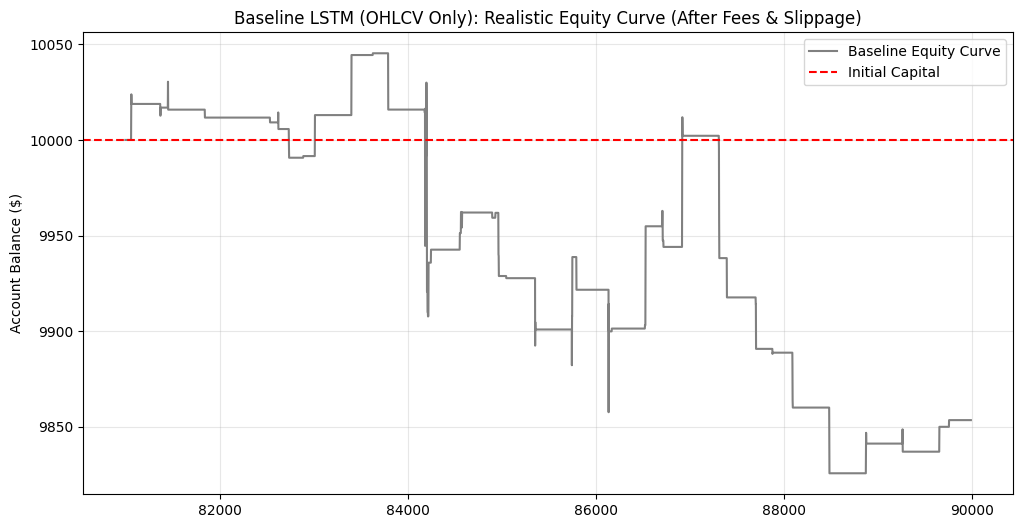

In [7]:
# --- 8. FINANCIAL BACKTESTING ---
# Align the test predictions with the original DataFrame
df_test = df_baseline.iloc[-len(probs):].copy()
df_test['Prob_Up'] = probs

# Using a threshold to only take confident trades
CONFIDENCE_THRESHOLD = 0.55
df_test['Signal'] = (df_test['Prob_Up'] > CONFIDENCE_THRESHOLD).astype(int)

# SLIPPAGE MODELING: Signal at T, Execute at T+1 Open, Exit at T+1 Close
df_test['Exec_Price'] = df_test['Open'].shift(-1)
df_test['Exit_Price'] = df_test['Close'].shift(-1)

# Drop the final row as it has no T+1 data
df_test = df_test.dropna(subset=['Exec_Price', 'Exit_Price']).copy()

# VARIABLES
INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009 
current_capital = INITIAL_CAPITAL
capital_history = []

# SIMULATION LOOP
for idx, row in df_test.iterrows():
    if row['Signal'] == 1:
        # 1. Number of shares afforded at the slipped execution price
        shares = np.floor(current_capital / row['Exec_Price'])
        
        # 2. Gross PnL from the minute's price action (Exit - Entry)
        gross_pnl = (row['Exit_Price'] - row['Exec_Price']) * shares
        
        # 3. Transaction Costs ($0.009 per share)
        fees = shares * FEE_PER_SHARE
        
        # 4. Update Capital
        current_capital += (gross_pnl - fees)
        
    capital_history.append(current_capital)

df_test['Account_Balance'] = capital_history
net_profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("       BASELINE FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Net Profit/Loss:         ${net_profit:,.2f}")
print(f"Final Account Capital:   ${current_capital:,.2f}")
print(f"Total ROI:               {(net_profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

# --- 9. EQUITY CURVE PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Account_Balance'], color='gray', label='Baseline Equity Curve')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title('Baseline LSTM (OHLCV Only): Realistic Equity Curve (After Fees & Slippage)')
plt.ylabel('Account Balance ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()